In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import shap

In [2]:
df = pd.read_csv("qb_transfer_master.csv")

In [3]:
target = 'post_ppa'
features = [
    'years_in_college', 
    'prev_pass_yds', 
    'prev_pass_td', 
    'prev_avg_ppa', 
    'dest_off_ppa', 
    'dest_sp_offense', 
    'is_transfer'
]
df_clean = df.dropna(subset=[target] + features)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 767 entries, 1 to 1260
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        767 non-null    int64  
 1   athlete_id        767 non-null    int64  
 2   first_name        767 non-null    object 
 3   last_name         767 non-null    object 
 4   team              767 non-null    object 
 5   season            767 non-null    int64  
 6   post_ppa          767 non-null    float64
 7   years_in_college  767 non-null    int64  
 8   prev_pass_yds     767 non-null    int64  
 9   prev_pass_td      767 non-null    int64  
 10  prev_avg_ppa      767 non-null    float64
 11  dest_off_ppa      767 non-null    float64
 12  dest_sp_offense   767 non-null    float64
 13  is_transfer       767 non-null    int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 89.9+ KB


In [4]:
X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=612)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=612)

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5, 
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}



Model Accuracy on Test Set:
Mean Absolute Error (MAE): 43.9127
R-squared (R2) Score: 0.3471


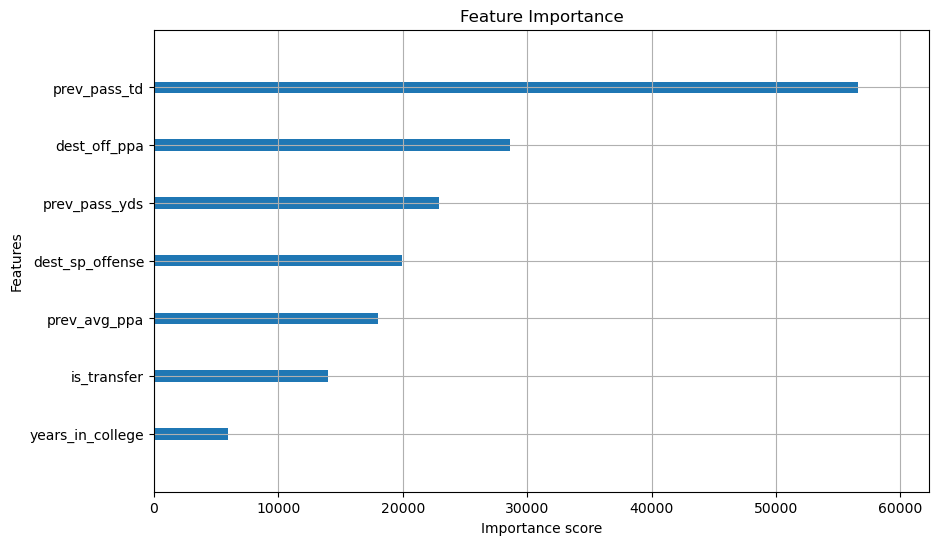

In [47]:
predictions = best_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\nModel Accuracy on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

plt.figure(figsize=(10, 6))
xgb.plot_importance(best_model, importance_type='gain', ax=plt.gca(), show_values=False)
plt.title("Feature Importance")
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=300)

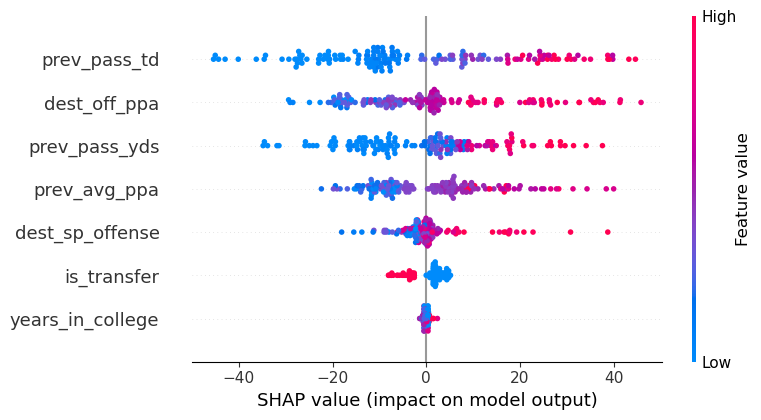

In [36]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features)

In [39]:
import joblib
joblib.dump(best_model, 'qb_xgb_model.pkl')

['qb_xgb_model.pkl']

In [44]:
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=300)
plt.close()